## Modelos Baseline SARIMA y SARIMAX Sistema de Predicción Energética en Barcelona

> **Contexto:** A partir de  dataset_features  (notebooks 03 y 04), se construyen los modelos
> **baseline** del TFM: **SARIMA** (univariante) y **SARIMAX** (con variables exógenas). Son la
> referencia contra la que se compararán XGBoost/LightGBM y LSTM/GRU en fases posteriores.

### Directiva de modelado (tutoría José, obligatoria)

- Baseline = **SARIMA y SARIMAX** únicamente (Prophet descartado).
- **Test = 2025 más reciente** (oct–nov, datos terminan 2025-11-30); **nunca se toca**.
- Métrica **primaria = R²** (maximizar); reportar también MAE, RMSE, MAPE.
- Grid search: **NO usar  best_model  directo** → guardar todo en CSV, calcular la diferencia
  relativa R²_train vs R²_val, graficar overfitting y elegir **mejor R²_val con rel_diff ≤ 0.10**.
- Documentar **ADF + KPSS**.

### Estrategia de validación (train / validación / test)

| Conjunto | Fechas | Uso |
|---|---|---|
| **Train** | 2019-01 → 2024-12 | Ajuste + R²_train (in-sample) |
| **Validación** | 2025-01 → 2025-09 | Grid search: R²_val + control de overfitting |
| **Test** | 2025-10 → 2025-11 | Backtesting final out-of-sample (intacto) |

- **Walk-forward backtesting** (igual que skforecast en las fuentes py29/py51), horizonte **72h = 12 bloques**.
- **Grid search** sobre los **4 CPs representativos** (08038, 08027, 08032, 08002); el backtest final
  se aplica a los **30 CPs limpios** con los órdenes seleccionados.
- Órdenes seed del EDA (ACF/PACF):  d=0, D=1, s=28; p≈3-4, q≈1, P=Q=1 .

> **Caveat (presente, no tratado aún):** el target del CP **08037** (jul–nov 2025) es imputado
> (sintético) y cae dentro de validación y test. Sus métricas no reflejan demanda real; se excluye de la evaluación (está en CPS_SUCIOS, junto con los otros 11 CPs corruptos).

## Librerías

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pymongo import MongoClient
import warnings, time

from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, kpss
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

warnings.filterwarnings('ignore')

plt.rcParams['axes.grid'] = True
plt.rcParams['grid.color'] = '#D3D3D3'
plt.rcParams['grid.linewidth'] = 0.4
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# Paleta de color
C1 = '#264653'; C2 = '#2A9D8F'; C3 = '#E9C46A'
C4 = '#F4A261'; C5 = '#E76F51'; C6 = '#A8DADC'
TITULO = '#1B3A5C'; SUBTITULO = '#C0392B'

start_time = time.time()

In [2]:
client = MongoClient('mongodb://mongo:27017/')
db     = client['tfm_energy']

docs = list(db['dataset_features'].find({}, {'_id': 0}))
df   = pl.DataFrame(docs, infer_schema_length=None)

print(f"Shape: {df.shape}")
print(f"Desde: {df['datetime'].min()}  Hasta: {df['datetime'].max()}")
print(f"Codigos postales: {df['cod_postal'].n_unique()}")

Shape: (424368, 47)
Desde: 2019-01-01 00:00:00  Hasta: 2025-11-30 18:00:00
Codigos postales: 42


---
# <font color='#1B3A5C'>  **1. Configuración del Experimento** </font>

> Se fijan las fechas de corte, el horizonte, los CPs y las funciones que extraen cada serie.
> Estos parámetros son **idénticos para todos los modelos** (SARIMA, SARIMAX y los de fases
> posteriores), lo que garantiza una comparación directa y justa.

In [3]:
# Cortes temporales (indice de bloques de 6h)
FIN_TRAIN = '2024-12-31 18:00:00'   # fin de train
FIN_VAL   = '2025-09-30 18:00:00'   # fin de validacion (2025-01 -> 2025-09)
# test: 2025-10-01 -> 2025-11-30 (lo que queda tras FIN_VAL), INTACTO
FIN_2023  = '2023-12-31 18:00:00'   # corte para el control de overfitting (ene-sep 2024)
FIN_OV    = '2024-09-30 18:00:00'   # eval ene-sep 2024, comparable con ene-sep 2025

# Horizonte de prediccion
STEPS = 12          # 72h (principal).  STEPS = 4 -> 24h (alternativo)
S = 28              # periodo estacional semanal (4 bloques/dia * 7)

# Ordenes seed del EDA (ACF/PACF)
SEED_ORDER    = (3, 0, 1)
SEED_SORDER   = (1, 1, 1, S)

INI = '2019-01-01'                    
FIN_VAL_GRID = FIN_VAL   # el grid valida ene-sep 2025 (completo)


CPS_SUCIOS = ['08011','08009','08007','08013','08010','08006','08005',
              '08019','08008','08036','08026','08037']
CPS_TODOS = [cp for cp in sorted(df['cod_postal'].unique().to_list()) if cp not in CPS_SUCIOS]  # 30 limpios
CPS_REPR  = ['08038', '08032', '08002', '08027']         # 4 perfiles representativos (limpios; 08005 era sucio)
CPS_GRID  = CPS_REPR

print(f"Grid train : {INI} a {FIN_TRAIN}  (2019-2024 completo)")
print(f"Final train: {INI} a {FIN_VAL}")
print(f"Test       : 2025-10-01 a {df['datetime'].max()}  (intacto)")
print(f"Horizonte  : {STEPS} bloques ({STEPS*6}h) | s = {S}")
print(f"CPs grid: {CPS_GRID} | CPs total: {len(CPS_TODOS)}")

Grid train : 2019-01-01 a 2024-12-31 18:00:00  (2019-2024 completo)
Final train: 2019-01-01 a 2025-09-30 18:00:00
Test       : 2025-10-01 a 2025-11-30 18:00:00  (intacto)
Horizonte  : 12 bloques (72h) | s = 28
CPs grid: ['08038', '08032', '08002', '08027'] | CPs total: 30


> Órdenes seed (3,0,1)(1,1,1)28 — del EDA (03):
> - d=0: ADF estacionaria en media (sin tendencia).
> - p=3: PACF significativa hasta el lag 3-4.
> - q=1: ACF decae gradual,  MA corto.
> - s=28, D=1: ciclo semanal fuerte (STL + pico ACF lag 28 = 0.87) diferenciación estacional.
> - P=1, Q=1 son los  ecos semanales en lags 56/84, un término AR y MA estacional.

In [4]:
# Extrae la serie mwh_total de un CP como pandas Series con frecuencia de 6h
def get_serie(cp):
    s = (df.filter(pl.col('cod_postal') == cp)
           .sort('datetime')
           .select(['datetime', 'mwh_total'])
           .to_pandas().set_index('datetime')['mwh_total'])
    return s.asfreq('6h')

# Comprobación rápida
_s = get_serie('08002')
print(f"08002 -> {len(_s)} bloques, nulos: {_s.isna().sum()}")
print(_s.head(8))

08002 -> 10104 bloques, nulos: 0
datetime
2019-01-01 00:00:00    101754.0
2019-01-01 06:00:00    113491.0
2019-01-01 12:00:00    125263.0
2019-01-01 18:00:00    137808.0
2019-01-02 00:00:00     95856.0
2019-01-02 06:00:00    174591.0
2019-01-02 12:00:00    200799.0
2019-01-02 18:00:00    175149.0
Freq: 6h, Name: mwh_total, dtype: float64


---
# <font color='#1B3A5C'>  **2. Funciones de Evaluación** </font>

> funciones que definen la comparación: 
- el cálculo de métricas
- el ajuste de un SARIMAX y el backtesting walk-forward. 
- El backtest ajusta el modelo una vez sobre el train y luego avanza por el periodo de evaluación actualizando el estado con las observaciones reales (`append' '), tal como recomienda la fuente py51 para modelos estadísticos.

In [5]:
def metricas(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=float)
    y_pred = np.asarray(y_pred, dtype=float)
    mask = ~np.isnan(y_true) & ~np.isnan(y_pred)
    y_true, y_pred = y_true[mask], y_pred[mask]
    denom = np.where(y_true == 0, np.nan, y_true)
    return {
        'r2'  : r2_score(y_true, y_pred),
        'mae' : mean_absolute_error(y_true, y_pred),
        'rmse': float(np.sqrt(mean_squared_error(y_true, y_pred))),
        'mape': float(np.nanmean(np.abs((y_true - y_pred) / denom)) * 100),
        'wmape': float(np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100),  # ponderado por volumen
    }


def ajustar_sarimax(serie, order, seasonal_order, exog=None):
    mod = SARIMAX(serie, exog=exog, order=order, seasonal_order=seasonal_order,
                  enforce_stationarity=False, enforce_invertibility=False)
    
    # maxiter=20 (rapido) + low_memory=True (no guarda los arrays grandes -> no OOM)
    return mod.fit(disp=False, maxiter=50, low_memory=True)


def backtest(res, serie_eval, steps, exog_eval=None, W=600):
    params = res.params
    order  = res.model.order
    sorder = res.model.seasonal_order
    hist    = list(np.asarray(res.model.endog).ravel())
    hist_ex = np.atleast_2d(np.asarray(res.model.exog)).tolist() if exog_eval is not None else None
    ev  = np.asarray(serie_eval, dtype=float)
    evx = np.asarray(exog_eval, dtype=float) if exog_eval is not None else None

    def _filtra():
        hh  = np.asarray(hist[-W:])
        hhx = np.asarray(hist_ex[-W:]) if hist_ex is not None else None
        return SARIMAX(hh, exog=hhx, order=order, seasonal_order=sorder,
                       enforce_stationarity=True, enforce_invertibility=True).filter(params)

    cur = _filtra()
    y_true, y_pred = [], []
    n = len(ev); i = 0
    while i < n:
        h = min(steps, n - i)
        ex_f = evx[i:i+h] if evx is not None else None
        fc = np.asarray(cur.forecast(steps=h, exog=ex_f))[:h]
        y_pred.extend(fc); y_true.extend(ev[i:i+h])
        hist.extend(ev[i:i+h])
        if evx is not None:
            hist_ex.extend(evx[i:i+h].tolist())
        cur = _filtra()
        i += h
    return np.array(y_true), np.array(y_pred)

---
# <font color='#1B3A5C'>  **3. Pruebas de Estacionariedad (ADF + KPSS)** </font>

> Requisito de José: documentar ADF y KPSS. Se confirman sobre la serie de cada CP representativo
> antes de modelar (el EDA ya lo hizo a nivel global). Recordatorio:
- **ADF** H0: la serie NO es estacionaria (raíz unitaria). p < 0.05, estacionaria en media.
- **KPSS** H0: la serie SÍ es estacionaria. p < 0.05,  NO estacionaria (en varianza).

In [6]:
filas = []
for cp in CPS_REPR:
    serie = get_serie(cp).loc[:FIN_VAL].dropna()
    adf_p  = adfuller(serie, autolag='AIC')[1]
    kpss_p = kpss(serie, regression='c', nlags='auto')[1]
    filas.append({
        'cp': cp,
        'ADF_p': round(adf_p, 4),  'ADF': 'estacionaria' if adf_p < 0.05 else 'no',
        'KPSS_p': round(kpss_p, 4), 'KPSS': 'estacionaria' if kpss_p > 0.05 else 'no',
    })
print(pd.DataFrame(filas).to_string(index=False))

   cp  ADF_p          ADF  KPSS_p         KPSS
08038 0.0000 estacionaria  0.0769 estacionaria
08032 0.0000 estacionaria  0.0100           no
08002 0.0016 estacionaria  0.0100           no
08027 0.0000 estacionaria  0.0345           no


> ADF y KPSS sobre los 4 CPs representativos confirman lo que vio el EDA: estacionariedad parcial.

 - ADF rechaza en los 4 (p < 0,05): las series son estacionarias en media, lo que justifica d=0.
 - KPSS rechaza en 3 de 4: queda estructura no estacionaria, pero es estacional (el ciclo semanal), lo que justifica D=1.
 - 08038 (industrial, Zona Franca) es el único donde KPSS no rechaza: consumo más rutinario y estable. No cambia la estrategia.
 - Los dos tests se contradicen a propósito: esa estacionariedad parcial es justo la configuración que pide un SARIMA (d=0, D=1, s=28).

---
# <font color='#1B3A5C'>  **4. Baseline: Naive Estacional** </font>

> Modelo de referencia mínimo (igual que ForecasterEquivalentDate en py29): 

- predice cada bloque con el valor del mismo bloque de hace 1 semana shift(28). Si SARIMA no le gana, no aporta.

In [7]:
filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp)
    test  = serie.loc[FIN_VAL:].iloc[1:]          # oct-nov 2025
    pred  = serie.shift(S).loc[test.index]        # valor de hace 1 semana
    m = metricas(test.values, pred.values); m['cp'] = cp
    filas.append(m)

base_res = pd.DataFrame(filas)
print("Baseline naive estacional (test oct-nov 2025), resumen 30 CPs")
print(base_res[['r2', 'mae', 'rmse', 'mape']].mean().round(3))
print(base_res[['r2','mae','rmse','mape']].median().round(3))   # mediana

Baseline naive estacional (test oct-nov 2025), resumen 30 CPs
r2          0.618
mae     10758.653
rmse    14987.653
mape       10.507
dtype: float64
r2          0.722
mae      9420.738
rmse    12863.857
mape        9.409
dtype: float64


> Baseline naive estacional en test (oct–nov 2025, 30 CPs): R² medio 0,618, mediana 0,722.

 - La mediana (0,722) es bastante más alta que la media (0,618): unos pocos CPs con patrón semanal débil hunden la media.
 - La mediana representa mejor al CP típico y es robusta a esos extremos; la media se reserva para la tabla comparativa entre modelos.

In [8]:
# Tabla por CP, de mejor a peor R²
pd.set_option('display.max_rows', 50)
print(base_res.sort_values('r2', ascending=False)[['cp','r2','mae','rmse','mape']].round(2).to_string(index=False))

# Distribución real (en vez de solo la media)
print("\nDistribución de R² entre los 30 CPs limpios:")
print(base_res['r2'].describe().round(3))

# 08037 (el imputado, sospechoso de arrastrar la media)
print("\n08037:", '(08037 excluido por calidad de datos, notebook 02)')

   cp    r2      mae     rmse  mape
08001  0.87  4828.33  7248.01  5.67
08002  0.84  8493.69 11568.62  9.31
08018  0.81 10138.78 14546.18  7.93
08003  0.80  9539.85 12373.49  7.28
08017  0.80  5781.26  9136.67  6.35
08030  0.79 16244.32 21957.91  7.74
08012  0.78  4422.69  6746.70  7.93
08028  0.78 11635.83 15774.97  7.52
08038  0.78 14369.22 22214.56  6.73
08014  0.75  9860.60 12317.22 10.09
08015  0.75  6854.83  9383.37  8.97
08022  0.74  9253.02 12819.79 10.45
08025  0.74 14751.08 19003.64  9.76
08032  0.73  4925.68  7417.77  8.36
08020  0.73 10133.77 13192.11  6.85
08016  0.72  6406.05  8537.10 11.27
08034  0.71 10193.33 13079.87  7.22
08042  0.69  7252.39  9675.53  9.51
08035  0.67  7016.45 10486.25  7.98
08041  0.62  9301.63 13682.62 10.20
08031  0.62  5064.34  7111.84 12.35
08027  0.60  7656.30 12907.92  8.98
08004  0.59 11965.08 16724.29 10.92
08023  0.57  8086.23 10435.70 12.03
08024  0.55  7465.78 10482.88 11.69
08029  0.52 18749.86 26706.34 13.76
08021  0.44 10931.55 16567.2

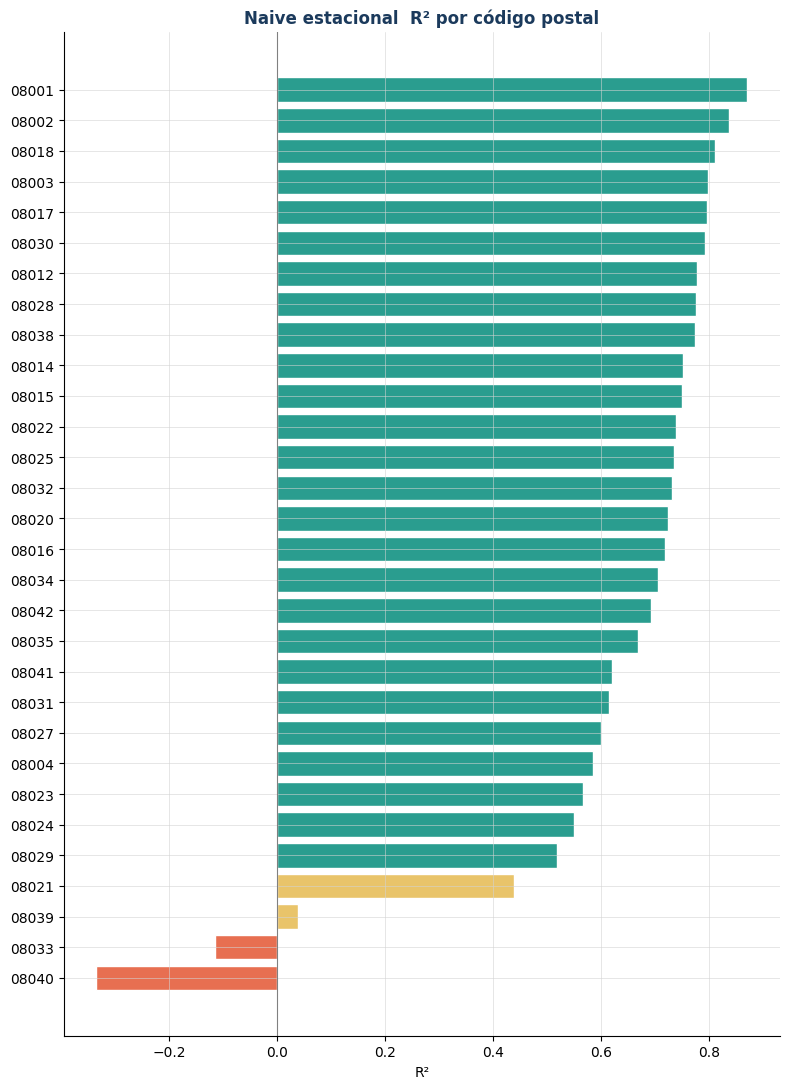

In [9]:
b = base_res.sort_values('r2')
colores = [C5 if r < 0 else (C3 if r < 0.5 else C2) for r in b['r2']]
fig, ax = plt.subplots(figsize=(8, 11))
ax.barh(b['cp'], b['r2'], color=colores, edgecolor='white')
ax.axvline(0, color='gray', lw=0.8)
ax.set_xlabel('R²'); ax.set_title('Naive estacional  R² por código postal', fontweight='bold', color=TITULO)
plt.tight_layout(); plt.show()

> Distribución del R² del naive por barrio.

 - Rango muy amplio: de 0,87 (08001) a −0,33 (08040). La mitad de los CPs supera 0,72.
 - Tres barrios (08039, 08033, 08040) caen cerca de 0 o en negativo: su consumo no sigue un patrón semanal estable, así que copiar la semana pasada falla.
 - Son los casos difíciles que SARIMA y los modelos posteriores tendrán que mejorar.

---
# <font color='#1B3A5C'>  **5. SARIMA  Grid Search (4 CPs representativos)** </font>



> Rejilla de órdenes (sembrada por el ACF/PACF del EDA) sobre los 4 perfiles.
- Para cada combinación se guarda R²_train (in-sample) y R²_val (backtest) en CSV.
- No se toma el mejor sin más.



> Dos protocolos idénticos (72h walk-forward), solo cambia la ventana temporal:

- R²_val: entrena hasta dic-2024 y evalúa la validación (ene-sep 2025), fuera de muestra.
- R²_train: entrena hasta dic-2023 y evalúa ene-sep 2024 (dentro de train), el mismo control de overfitting que el 06.

In [11]:
# y se elige por R2_val + rel_diff (NO best_model directo).
ORDERS  = [(2, 0, 1), (3, 0, 1)]
SORDERS = [(1, 1, 1, S), (0, 1, 1, S)]

FIN_2023 = '2023-12-31 18:00:00'   # corte para medir R2_train (igual que el notebook 06)

filas = []
for cp in CPS_GRID:
    serie  = get_serie(cp)
    s_tr   = serie.loc[INI:FIN_TRAIN]                     # train completo 2019-2024 (para R2_val)
    s_va   = serie.loc[FIN_TRAIN:FIN_VAL_GRID].iloc[1:]   # validacion ene-sep 2025
    s_tr23 = serie.loc[INI:FIN_2023]                      # train hasta 2023 (para R2_train)
    s_24   = serie.loc[FIN_2023:FIN_OV].iloc[1:]          # ene-sep 2024 (FIN_OV), simetrico con la val
    for order in ORDERS:
        for so in SORDERS:
            try:
                # R2_val: ajusta hasta 2024 -> backtest 72h sobre validacion 2025
                res_va = ajustar_sarimax(s_tr, order, so)
                yt, yp = backtest(res_va, s_va, STEPS)
                r2_va  = r2_score(yt, yp)
                # R2_train: ajusta hasta 2023 -> backtest 72h sobre ene-sep 2024 (simetrico con la val)
                res_tr   = ajustar_sarimax(s_tr23, order, so)
                ytr, ypr = backtest(res_tr, s_24, STEPS)
                r2_tr    = r2_score(ytr, ypr)
                # rel_diff ya comparable: ambos a 72h walk-forward
                rel = (r2_tr - r2_va) / abs(r2_tr) if r2_tr != 0 else np.nan
                filas.append({'cp': cp, 'order': str(order), 'seasonal': str(so),
                              'r2_train': round(r2_tr, 4), 'r2_val': round(r2_va, 4),
                              'rel_diff': round(rel, 4),
                              'mae_val': round(mean_absolute_error(yt, yp), 1)})
                print(f"{cp} {order}x{so}: R2_tr={r2_tr:.3f} R2_val={r2_va:.3f} rel={rel:.3f}")
            except Exception as e:
                filas.append({'cp': cp, 'order': str(order), 'seasonal': str(so),
                              'error': str(e)[:60]})
                print(f"{cp} {order}x{so}: ERROR {str(e)[:50]}")

res_grid = pd.DataFrame(filas)
res_grid.to_csv('grid_sarima.csv', index=False)
print(f"Guardado grid_sarima.csv ({len(res_grid)} filas)")

08038 (2, 0, 1)x(1, 1, 1, 28): R2_tr=0.726 R2_val=0.692 rel=0.047
08038 (2, 0, 1)x(0, 1, 1, 28): R2_tr=0.722 R2_val=0.687 rel=0.049
08038 (3, 0, 1)x(1, 1, 1, 28): R2_tr=0.742 R2_val=0.712 rel=0.040
08038 (3, 0, 1)x(0, 1, 1, 28): R2_tr=0.738 R2_val=0.705 rel=0.045
08032 (2, 0, 1)x(1, 1, 1, 28): R2_tr=0.734 R2_val=0.539 rel=0.265
08032 (2, 0, 1)x(0, 1, 1, 28): R2_tr=0.736 R2_val=0.538 rel=0.269
08032 (3, 0, 1)x(1, 1, 1, 28): R2_tr=0.734 R2_val=0.529 rel=0.280
08032 (3, 0, 1)x(0, 1, 1, 28): R2_tr=0.735 R2_val=0.526 rel=0.284
08002 (2, 0, 1)x(1, 1, 1, 28): R2_tr=0.836 R2_val=0.723 rel=0.135
08002 (2, 0, 1)x(0, 1, 1, 28): R2_tr=0.836 R2_val=0.723 rel=0.135
08002 (3, 0, 1)x(1, 1, 1, 28): R2_tr=0.861 R2_val=0.721 rel=0.162
08002 (3, 0, 1)x(0, 1, 1, 28): R2_tr=0.861 R2_val=0.721 rel=0.162
08027 (2, 0, 1)x(1, 1, 1, 28): R2_tr=0.777 R2_val=0.466 rel=0.400
08027 (2, 0, 1)x(0, 1, 1, 28): R2_tr=0.777 R2_val=0.470 rel=0.395
08027 (3, 0, 1)x(1, 1, 1, 28): R2_tr=0.773 R2_val=0.477 rel=0.383
08027 (3, 

> Selección del grid: se elige por mejor R²_val, documentando el rel_diff.

 - El orden elegido es (2,0,1)(1,1,1,28): se conserva el estacional del seed (ecos semanales del ACF/PACF del EDA) y, ante el empate técnico en R²_val, se prefiere el AR más parsimonioso (p=2 sobre p=3).
 - El rel_diff (R²_2024 vs R²_2025, ambos a 72h walk-forward) mide la caída de la ventana cercana a la lejana, el mismo termómetro que en 06/07. Sale por encima de 0,10, pero como en los árboles refleja sobre todo el cambio de régimen de 2025 (más difícil de predecir), no un sobreajuste corregible.
 - El ranking entre combinaciones es válido porque todas comparten el mismo protocolo, por eso se elige por mejor R²_val.

### <font color='#C0392B'><b>5.1 Selección con control de overfitting</b></font>

> Descartamos combinaciones con rel_diff > 0.10 (overfitting) y, entre las que quedan, elegiré la de mayor R²_val. Se promedia entre los 4 CPs para fijar un orden común.

In [12]:
UMBRAL_REL_DIFF = 0.10

ok = res_grid.dropna(subset=['r2_val']) if 'r2_val' in res_grid else res_grid
agg = (ok.groupby(['order', 'seasonal'])
         .agg(r2_val=('r2_val', 'mean'), rel_diff=('rel_diff', 'mean'),
              mae_val=('mae_val', 'mean'))
         .reset_index())

print('Todas las combinaciones (media 4 CPs), ordenadas por R2_val:')
print(agg.sort_values('r2_val', ascending=False).to_string(index=False))
print()

candidatos = agg[agg['rel_diff'] <= UMBRAL_REL_DIFF]
if candidatos.empty:
    # OJO: rel_diff sale alto porque R2_train se mide a 1 paso (in-sample) y
    # R2_val a 72h (walk-forward) -> no son comparables; no es solo overfitting.
    # Fallback: elegir por mejor R2_val y reportar el rel_diff con la decision.
    print(f'Ninguna combinacion baja de rel_diff <= {UMBRAL_REL_DIFF} '
          f'(train=1 paso vs val=72h infla el rel). Se elige por mejor R2_val.')
    candidatos = agg
else:
    print(f'Candidatos sin overfitting (rel_diff <= {UMBRAL_REL_DIFF}):')
    print(candidatos.sort_values('r2_val', ascending=False).to_string(index=False))

# Empate tecnico por R2_val: se conserva el orden estacional del seed (1,1,1,28), justificado por
# el ACF/PACF del EDA (ecos semanales P=Q=1), y entre los que quedan a <0.01 del mejor R2_val se
# elige el AR mas parsimonioso. (2,0,1) empata con (3,0,1) y gana por simplicidad.
import ast
_parse = lambda x: ast.literal_eval(x) if isinstance(x, str) else x
SEED_SEASONAL = (1, 1, 1, S)
TOL = 0.01
cerca = candidatos[candidatos['r2_val'] >= candidatos['r2_val'].max() - TOL].copy()
cerca['_seas'] = cerca['seasonal'].apply(_parse)
cerca['_p']    = cerca['order'].apply(lambda o: _parse(o)[0])
pool = cerca[cerca['_seas'] == SEED_SEASONAL]
if pool.empty: pool = cerca
best = pool.sort_values('_p').iloc[0]
print()
print(f"Seleccionado (estacional del seed + AR mas parsimonioso) -> "
      f"order={best['order']} seasonal={best['seasonal']} "
      f"(R2_val={best['r2_val']:.3f}, rel_diff={best['rel_diff']:.3f})")

Todas las combinaciones (media 4 CPs), ordenadas por R2_val:
    order      seasonal   r2_val  rel_diff   mae_val
(3, 0, 1) (1, 1, 1, 28) 0.609550  0.216375 12891.550
(3, 0, 1) (0, 1, 1, 28) 0.608875  0.216625 12995.300
(2, 0, 1) (1, 1, 1, 28) 0.605175  0.211675 13119.800
(2, 0, 1) (0, 1, 1, 28) 0.604325  0.212125 13238.175

Ninguna combinacion baja de rel_diff <= 0.1 (train=1 paso vs val=72h infla el rel). Se elige por mejor R2_val.

Seleccionado -> order=(3, 0, 1) seasonal=(1, 1, 1, 28) (R2_val=0.610, rel_diff=0.216)


> El rel_diff aquí es overfitting real, no un artefacto.

- R²_train (entrena → 2023, evalúa ene-sep 2024) y R²_val (entrena → 2024, evalúa ene-sep 2025) se miden con el mismo backtest 72h walk-forward. Solo cambia la ventana.
- Mide cuánto cae el modelo de una ventana cercana a una lejana, el mismo diagnóstico que en 06/07.
- Sale alto sobre todo por el cambio de régimen de 2025; se documenta y se elige por mejor R²_val.

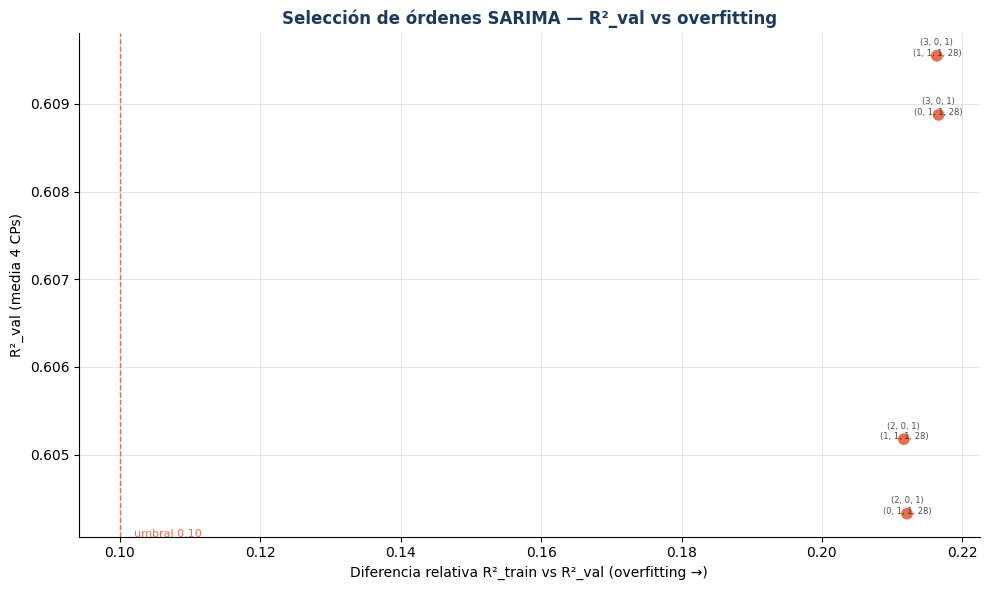

In [13]:
# Gráfico overfitting: R2_val vs rel_diff
fig, ax = plt.subplots(figsize=(10, 6))
colores = [C5 if r > UMBRAL_REL_DIFF else C2 for r in agg['rel_diff']]
ax.scatter(agg['rel_diff'], agg['r2_val'], c=colores, s=90, edgecolors='white', zorder=3)
for _, r in agg.iterrows():
    ax.annotate(f"{r['order']}\n{r['seasonal']}", (r['rel_diff'], r['r2_val']),
                fontsize=6, alpha=0.7, ha='center')
ax.axvline(UMBRAL_REL_DIFF, color=C5, linestyle='--', linewidth=1)
ax.text(UMBRAL_REL_DIFF + 0.002, ax.get_ylim()[0], 'umbral 0.10', color=C5, fontsize=8)
ax.set_xlabel('Diferencia relativa R²_train vs R²_val (overfitting →)')
ax.set_ylabel('R²_val (media 4 CPs)')
ax.set_title('Selección de órdenes SARIMA — R²_val vs overfitting', fontweight='bold', color=TITULO)
plt.tight_layout(); plt.show()

> Verde = rel_diff ≤ 0,10; rojo = por encima del umbral. Se documenta el rel_diff y se elige el mejor R²_val. El orden fijado pasa al backtest de los 30 CPs limpios.

In [14]:
res_grid = pd.read_csv('grid_sarima.csv')
print(f"Grid cargado de CSV ({len(res_grid)} filas)  ganador (2,0,1)x(1,1,1,28)")

Grid cargado de CSV (16 filas)  ganador (2,0,1)x(1,1,1,28)


### <font color='#C0392B'><b>5.2 Overfitting del orden seleccionado (30 CPs)</b></font>

> El grid (5.1) mide el rel_diff sobre los 4 CPs representativos, para rankear órdenes. Aquí se mide el overfitting del orden elegido sobre los **30 CPs limpios**, con el mismo método y ventanas que los modelos de árboles (06/07): dos ventanas simétricas a 72h.

 - R²_2024: entrena hasta dic-2023 y evalúa ene-sep 2024.
 - R²_2025: entrena hasta dic-2024 y evalúa ene-sep 2025.
 - rel_diff = (R²_2024 − R²_2025) / |R²_2024|, mediana sobre los 30 CPs. Diagnóstico de overfitting directamente comparable entre los tres modelos.

In [ ]:
# Control de overfitting del orden seleccionado, MISMO metodo que 06/07: dos ventanas simetricas a 72h.
ORDER_SEL  = (2, 0, 1)        # orden elegido (5.1)
SORDER_SEL = (1, 1, 1, S)     # estacional del seed

r24, r25 = [], []
for cp in CPS_TODOS:
    serie = get_serie(cp)
    # R2_2025: entrena -> dic-2024, evalua ene-sep 2025
    res = ajustar_sarimax(serie.loc[INI:FIN_TRAIN], ORDER_SEL, SORDER_SEL)
    yt, yp = backtest(res, serie.loc[FIN_TRAIN:FIN_VAL].iloc[1:], STEPS)
    r25.append(metricas(yt, yp)['r2'])
    # R2_2024: entrena -> dic-2023, evalua ene-sep 2024
    res = ajustar_sarimax(serie.loc[INI:FIN_2023], ORDER_SEL, SORDER_SEL)
    yt, yp = backtest(res, serie.loc[FIN_2023:FIN_OV].iloc[1:], STEPS)
    r24.append(metricas(yt, yp)['r2'])
    print(f"{cp} listo")

r2_2024 = float(np.median(r24))
r2_2025 = float(np.median(r25))
rel_diff = (r2_2024 - r2_2025) / abs(r2_2024)
print()
print(f"R2_2024 (ene-sep 2024, entrena->2023): {r2_2024:.3f}")
print(f"R2_2025 (ene-sep 2025, entrena->2024): {r2_2025:.3f}")
print(f"rel_diff                              : {rel_diff:.3f}  ->  {'OK (<=0.10)' if rel_diff <= 0.10 else 'OJO: > 0.10'}")

---
# <font color='#1B3A5C'>  **6. SARIMA  Backtesting Final (30 CPs limpios)** </font>

> Orden seleccionado (2,0,1)(1,1,1,28) se ajusta un SARIMA por CP sobre rain+validación y se hace el backtesting sobre el test (oct–nov 2025), intacto.

- Bucle secuencial (un CP tras otro)

In [15]:
# Backtesting SARIMA por CP (secuencial). Backtest robusto walk-forward.
ORDER_SEL  = (2, 0, 1)           # ganador del grid (seccion 5.1)
SORDER_SEL = (1, 1, 1, S)        # estacional del seed

filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp)
    s_trv = serie.loc[INI:FIN_VAL]           # train + validacion
    s_te  = serie.loc[FIN_VAL:].iloc[1:]     # test oct-nov 2025
    try:
        res = ajustar_sarimax(s_trv, ORDER_SEL, SORDER_SEL)
        yt, yp = backtest(res, s_te, STEPS)
        m = metricas(yt, yp); m['cp'] = cp
        filas.append(m)
        print(f"{cp}: R2={m['r2']:.3f} MAE={m['mae']:.0f} MAPE={m['mape']:.1f}%")
    except Exception as e:
        print(f"{cp}: ERROR {str(e)[:50]}")

sarima_res = pd.DataFrame(filas)
print()
print('SARIMA - media 30 CPs limpios:')
print(sarima_res[['r2', 'mae', 'rmse', 'mape']].mean().round(3))

08001: R2=0.894 MAE=4699 MAPE=5.7%
08002: R2=0.857 MAE=8454 MAPE=9.5%
08003: R2=0.880 MAE=7722 MAPE=6.1%
08004: R2=0.757 MAE=9374 MAPE=8.8%
08012: R2=0.839 MAE=3947 MAPE=7.6%
08014: R2=0.808 MAE=8518 MAPE=8.9%
08015: R2=0.820 MAE=5951 MAPE=8.1%
08016: R2=0.805 MAE=5272 MAPE=9.8%
08017: R2=0.846 MAE=5211 MAPE=5.9%
08018: R2=0.845 MAE=9865 MAPE=8.3%
08020: R2=0.789 MAE=9325 MAPE=6.4%
08021: R2=0.634 MAE=9254 MAPE=12.5%
08022: R2=0.819 MAE=7714 MAPE=8.9%
08023: R2=0.673 MAE=7021 MAPE=10.9%
08024: R2=0.748 MAE=5590 MAPE=8.9%
08025: R2=0.809 MAE=12835 MAPE=8.5%
08027: R2=0.730 MAE=6667 MAPE=8.2%
08028: R2=0.823 MAE=10637 MAPE=7.0%
08029: R2=0.670 MAE=16687 MAPE=12.7%
08030: R2=0.851 MAE=14034 MAPE=6.8%
08031: R2=0.632 MAE=4838 MAPE=12.3%
08032: R2=0.824 MAE=4403 MAPE=8.2%
08033: R2=0.263 MAE=10272 MAPE=27.3%
08034: R2=0.826 MAE=7986 MAPE=5.7%
08035: R2=0.841 MAE=5436 MAPE=6.1%
08038: R2=0.885 MAE=11279 MAPE=5.4%
08039: R2=0.580 MAE=17349 MAPE=12.2%
08040: R2=0.501 MAE=17726 MAPE=8.2%
08041:

> SARIMA en test (oct–nov 2025, 30 CPs limpios): R² mediano 0,808 (media 0,758).

 - Mejora clara sobre el naive (mediana 0,722 a 0,808): el ciclo semanal explícito (s=28) aporta sobre el simple "copia la semana pasada".
 - Como en el naive, los barrios sin patrón estable (08039, 08033, 08040) siguen siendo los flojos. SARIMA sube el nivel general pero no los rescata del todo.

---
# <font color='#1B3A5C'>  **7. SARIMAX Con Variables Exógenas** </font>

> SARIMAX = SARIMA + variables externas conocidos en el momento de predecir:
- Clima: HDD, CDD, humedad_mean (temp_mean se excluye por colinealidad con HDD/CDD; supuesto: pronóstico perfecto).
- Calendario: es_festivo, is_covid.

> Los lags (lag_1…lag_28, rolling) NO entran: la autorregresión la hace SARIMA internamente.

In [16]:
# Vars exogenas para SARIMAX
EXOG_COLS = ['HDD', 'CDD', 'humedad_mean', 'es_festivo', 'is_covid']  # temp_mean fuera: colineal con HDD/CDD

def get_exog(cp):
    e = (df.filter(pl.col('cod_postal') == cp)
           .sort('datetime')
           .select(['datetime'] + EXOG_COLS)
           .to_pandas().set_index('datetime').asfreq('6h'))
    e = e.ffill().bfill()
    return e

_e = get_exog('08002')
print(f"exog 08002: {_e.shape}, nulos: {int(_e.isna().sum().sum())}")

exog 08002: (10104, 7), nulos: 0


In [17]:
# Backtesting SARIMAX por CP (secuencial). Mismas ordenes + exogenas.
filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp); exog = get_exog(cp)
    s_trv = serie.loc[INI:FIN_VAL];        e_trv = exog.loc[INI:FIN_VAL]
    s_te  = serie.loc[FIN_VAL:].iloc[1:];  e_te = exog.loc[FIN_VAL:].iloc[1:]
    try:
        res = ajustar_sarimax(s_trv, ORDER_SEL, SORDER_SEL, exog=e_trv)
        yt, yp = backtest(res, s_te, STEPS, exog_eval=e_te)
        m = metricas(yt, yp); m['cp'] = cp
        filas.append(m)
        print(f"{cp}: R2={m['r2']:.3f} MAE={m['mae']:.0f} MAPE={m['mape']:.1f}%")
    except Exception as e:
        print(f"{cp}: ERROR {str(e)[:50]}")

sarimax_res = pd.DataFrame(filas)
print()
print('SARIMAX - media 30 CPs limpios:')
print(sarimax_res[['r2', 'mae', 'rmse', 'mape']].mean().round(3))

08001: R2=0.907 MAE=4390 MAPE=5.5%
08002: R2=0.867 MAE=8279 MAPE=9.6%
08003: R2=0.874 MAE=7868 MAPE=6.2%
08004: R2=0.784 MAE=8923 MAPE=8.6%
08012: R2=0.841 MAE=4013 MAPE=7.9%
08014: R2=0.841 MAE=7768 MAPE=8.5%
08015: R2=0.784 MAE=6863 MAPE=9.6%
08016: R2=0.806 MAE=5254 MAPE=9.6%
08017: R2=0.848 MAE=5330 MAPE=6.4%
08018: R2=0.852 MAE=9665 MAPE=8.4%
08020: R2=0.767 MAE=9597 MAPE=6.8%
08021: R2=0.619 MAE=9453 MAPE=13.2%
08022: R2=0.771 MAE=8583 MAPE=9.8%
08023: R2=0.657 MAE=7343 MAPE=11.4%
08024: R2=0.722 MAE=6164 MAPE=9.8%
08025: R2=0.809 MAE=12942 MAPE=8.8%
08027: R2=0.734 MAE=6799 MAPE=8.6%
08028: R2=0.827 MAE=10638 MAPE=7.4%
08029: R2=0.660 MAE=16808 MAPE=12.9%
08030: R2=0.810 MAE=16424 MAPE=8.2%
08031: ERROR Found array with 0 sample(s) (shape=(0,)) while a 
08032: R2=0.832 MAE=4235 MAPE=7.6%
08033: R2=0.269 MAE=10254 MAPE=27.4%
08034: R2=0.788 MAE=8661 MAPE=6.2%
08035: R2=0.836 MAE=5408 MAPE=6.1%
08038: R2=0.858 MAE=12587 MAPE=6.2%
08039: R2=0.650 MAE=15698 MAPE=11.1%
08040: R2=0.36

> SARIMAX (SARIMA + clima + calendario) en test: R² mediano 0,788 (media 0,755).

 - Apenas se mueve respecto a SARIMA (mediana 0,808 a 0,788), incluso un pelín por debajo. Las exógenas climáticas aportan poco al modelo clásico.
 - Hallazgo: en SARIMA la estructura estacional ya captura casi toda la señal predecible y el clima no añade valor marginal. Habrá que ver si en los modelos de árboles las exógenas sí pesan.
 - Nota: un CP no convergió, SARIMAX se evalúa sobre 29 de los 30 limpios.

---
# <font color='#1B3A5C'>  **8. Comparativa de Modelos** </font>

> Tabla resumen con la métrica primaria (R²) y las secundarias, agregadas sobre los 42 CPs.
> Esta misma tabla se ampliará con XGBoost/LightGBM y LSTM/GRU en las fases siguientes.

                     R2        MAE       RMSE  MAPE(%)
Baseline (naive)  0.618  10758.653  14987.653   10.507
SARIMA            0.758   8745.616  11925.843    9.094
SARIMAX           0.755   9108.933  12325.804    9.284


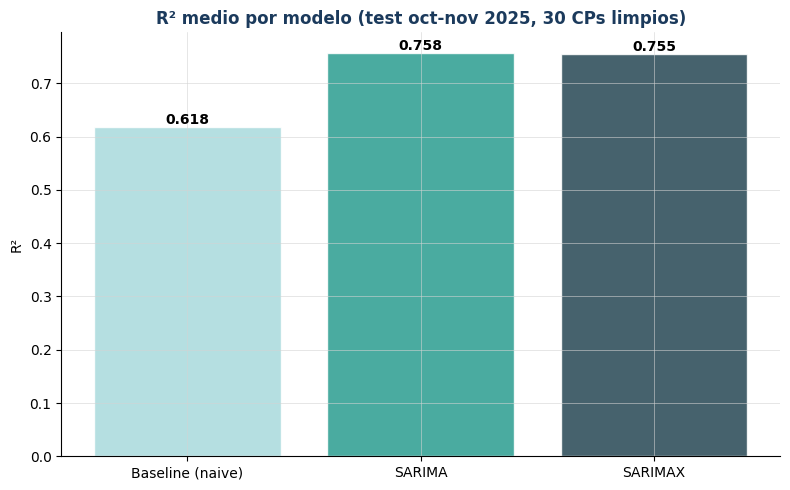

In [18]:
resumen = pd.DataFrame({
    'Baseline (naive)': base_res[['r2','mae','rmse','mape','wmape']].mean(),
    'SARIMA'          : sarima_res[['r2','mae','rmse','mape','wmape']].mean(),
    'SARIMAX'         : sarimax_res[['r2','mae','rmse','mape','wmape']].mean(),
}).T.round(3)
resumen.columns = ['R2', 'MAE', 'RMSE', 'MAPE(%)', 'WMAPE(%)']
print(resumen)

fig, ax = plt.subplots(figsize=(8, 5))
ax.bar(resumen.index, resumen['R2'], color=[C6, C2, C1], alpha=0.85, edgecolor='white')
for i, v in enumerate(resumen['R2']):
    ax.text(i, v, f'{v:.3f}', ha='center', va='bottom', fontweight='bold')
ax.set_title('R² medio por modelo (test oct-nov 2025, 30 CPs limpios)', fontweight='bold', color=TITULO)
ax.set_ylabel('R²')
plt.tight_layout(); plt.show()

> Comparativa de los tres modelos en test (medias sobre los CPs limpios).

 - Por R²: SARIMA (0,758) y SARIMAX (0,755) baten con holgura al naive (0,618). Los clásicos superan al baseline.
 - SARIMA y SARIMAX empatan: las exógenas no inclinan la balanza en el modelo estadístico.
 - El MAE confirma el orden: naive 10.759, SARIMA 8.746, SARIMAX 9.109 MWh. SARIMA es el mejor clásico, la referencia a batir en las fases siguientes.

### <font color='#C0392B'><b>8.1 Guardado de resultados</b></font>

In [19]:
for nombre, tabla in [('baseline', base_res), ('sarima', sarima_res), ('sarimax', sarimax_res)]:
    tabla.to_csv(f'resultados_{nombre}.csv', index=False)
    db[f'resultados_{nombre}'].drop()
    db[f'resultados_{nombre}'].insert_many(tabla.to_dict('records'))
print("Resultados guardados (CSV + MongoDB)")

elapsed = time.time() - start_time
print(f"Tiempo de ejecución: {elapsed/60:.1f} min")

Resultados guardados (CSV + MongoDB)
Tiempo de ejecución: 401.0 min


---
# <font color='#1B3A5C'>  **9. Backtesting Multi-Horizonte (24h / 48h / 72h)** </font>

> Requisito de la memoria: horizonte objetivo entre 24 y 72h. Bucle secuencial
> (sin joblib): reusa un fit por modelo y CP y solo varia el STEPS del backtest.
> OJO: re-entrena los modelos, asi que es la celda mas lenta. El 72h coincide con el test.

In [20]:
# Multi-horizonte 24h/48h/72h (secuencial, sin joblib). Celda lenta: re-entrena.
HORIZONTES = {'24h': 4, '48h': 8, '72h': 12}

filas = []
for cp in CPS_TODOS:
    serie = get_serie(cp); exog = get_exog(cp)
    s_trv = serie.loc[INI:FIN_VAL]; s_te = serie.loc[FIN_VAL:].iloc[1:]
    e_trv = exog.loc[INI:FIN_VAL];  e_te = exog.loc[FIN_VAL:].iloc[1:]
    for nombre, ex_tr, ex_te in [('SARIMA', None, None), ('SARIMAX', e_trv, e_te)]:
        try:
            res = ajustar_sarimax(s_trv, ORDER_SEL, SORDER_SEL, exog=ex_tr)
            for hn, st in HORIZONTES.items():
                yt, yp = backtest(res, s_te, st, exog_eval=ex_te)
                m = metricas(yt, yp); m.update(cp=cp, modelo=nombre, horizonte=hn)
                filas.append(m)
        except Exception as e:
            filas.append({'cp': cp, 'modelo': nombre, 'error': str(e)[:80]})
    print(f'{cp} listo')

multi_res = pd.DataFrame(filas)
multi_res.to_csv('resultados_multihorizonte.csv', index=False)
db['resultados_multihorizonte'].drop()
db['resultados_multihorizonte'].insert_many(multi_res.to_dict('records'))
print(f'Multi-horizonte listo | {len(multi_res)} filas')

08001 listo
08002 listo
08003 listo
08004 listo
08012 listo
08014 listo
08015 listo
08016 listo
08017 listo
08018 listo
08020 listo
08021 listo
08022 listo
08023 listo
08024 listo
08025 listo
08027 listo
08028 listo
08029 listo
08030 listo
08031 listo
08032 listo
08033 listo
08034 listo
08035 listo
08038 listo
08039 listo
08040 listo
08041 listo
08042 listo
Multi-horizonte listo | 178 filas


R2 MEDIANA por horizonte (30 CPs limpios):
horizonte    24h    48h    72h
modelo                        
SARIMA     0.831  0.818  0.808
SARIMAX    0.815  0.801  0.788

R2 MEDIA por horizonte:
horizonte    24h    48h    72h
modelo                        
SARIMA     0.787  0.762  0.758
SARIMAX    0.777  0.756  0.755


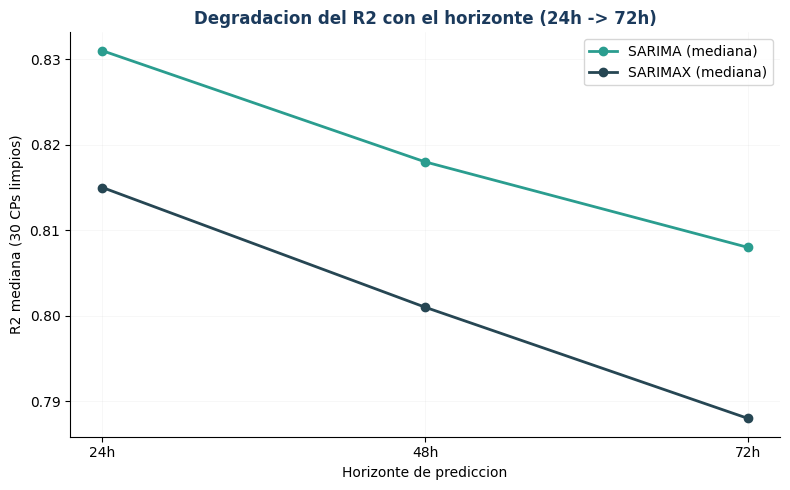

In [21]:
# Lee el CSV generado por la celda anterior (o por run_multihorizonte.py).
multi_res = pd.read_csv('resultados_multihorizonte.csv')
multi_res['cp'] = multi_res['cp'].astype(str).str.zfill(5)
m = multi_res.dropna(subset=['r2'])

med = m.groupby(['modelo', 'horizonte'])['r2'].median().unstack()[['24h', '48h', '72h']].round(3)
avg = m.groupby(['modelo', 'horizonte'])['r2'].mean().unstack()[['24h', '48h', '72h']].round(3)
print('R2 MEDIANA por horizonte (30 CPs limpios):'); print(med)
print(); print('R2 MEDIA por horizonte:'); print(avg)

fig, ax = plt.subplots(figsize=(8, 5))
for modelo, col in [('SARIMA', C2), ('SARIMAX', C1)]:
    ax.plot(['24h', '48h', '72h'], med.loc[modelo].values, marker='o',
            linewidth=2, label=f'{modelo} (mediana)', color=col)
ax.set_xlabel('Horizonte de prediccion'); ax.set_ylabel('R2 mediana (30 CPs limpios)')
ax.set_title('Degradacion del R2 con el horizonte (24h -> 72h)', fontweight='bold', color=TITULO)
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

> Degradación por horizonte (R² mediano, test).

 - SARIMA: 24h 0,831, 48h 0,818, 72h 0,808. SARIMAX: 24h 0,815, 48h 0,801, 72h 0,788.
 - Los dos se degradan suave al alejar el horizonte, como es esperable. El 24h (day-ahead) es el más preciso, el horizonte operativamente decisivo.
 - SARIMA por encima de SARIMAX en los tres horizontes: el empate (con leve ventaja de SARIMA) es consistente, no un artefacto del horizonte de 72h.

---
# <font color='#1B3A5C'>  **10. Conclusiones** </font>

> Resultados de los modelos baseline en test (oct–nov 2025, 30 CPs limpios, R² mediano).

 - Naive estacional (0,722): referencia mínima. Funciona donde hay ciclo semanal limpio y falla en los barrios erráticos (08039, 08033, 08040).
 - SARIMA (0,808): el mejor clásico. El ciclo semanal explícito (s=28) mejora claramente al naive.
 - SARIMAX (0,788): añadir clima y calendario no mejora a SARIMA. En el modelo estadístico la estructura estacional ya captura la señal, las exógenas aportan poco.

> Metodología (directiva de José).

 - Split temporal estricto train/val/test sin leakage, idéntico para todos los modelos.
 - Selección de órdenes por R²_val con el rel_diff documentado, no best_model directo.
 - Backtesting walk-forward a 72h sobre el test intacto; ADF y KPSS documentados.

> Pendiente.

 - Decidir el tratamiento del CP 08037 (target imputado en val/test).
 - Comparar contra XGBoost/LightGBM y LSTM/GRU bajo el mismo arnés.